In [5]:
import pandas as pd
import numpy as np

In [6]:
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("customer_shopping_behavior.csv")

In [5]:
df.shape

(3900, 18)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [7]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Review Rating"].mean()

np.float64(3.750064716541548)

In [10]:
df["Review Rating"] = df["Review Rating"].fillna(df["Review Rating"].mean())


In [11]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [12]:
# Convert column names to lowercase
df.columns = df.columns.str.lower()

# Replace spaces with underscore
df.columns = df.columns.str.replace(" ", "_")

# Remove brackets
df.columns = df.columns.str.replace("(", "", regex=False)
df.columns = df.columns.str.replace(")", "", regex=False)

# Remove USD text
df.columns = df.columns.str.replace("_usd", "", regex=False)

# Check updated columns
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [13]:
bins = [17, 25, 35, 50, 100]

labels = ["Young Adult", "Adult", "Middle Aged", "Senior"]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels
)

In [14]:
df[["age", "age_group"]].head(10)

,age,age_group
0,55,Senior
1,19,Young Adult
2,50,Middle Aged
3,21,Young Adult
4,45,Middle Aged
5,46,Middle Aged
6,63,Senior
7,27,Adult
8,26,Adult
9,57,Senior


In [15]:
df["age_group"].value_counts()

age_group
Senior         1476
Middle Aged    1111
Adult           742
Young Adult     571
Name: count, dtype: int64

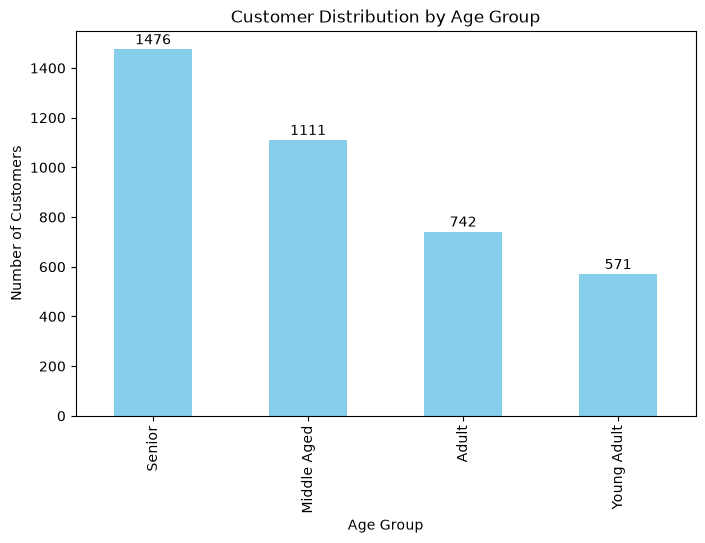

In [16]:
counts = df["age_group"].value_counts()

ax = counts.plot(
    kind="bar",
    color="skyblue",
    figsize=(8,5)
)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

# Bar ke upar values likhne ke liye
for i, value in enumerate(counts):
    plt.text(i, value + 20, str(value), ha="center")

plt.show()

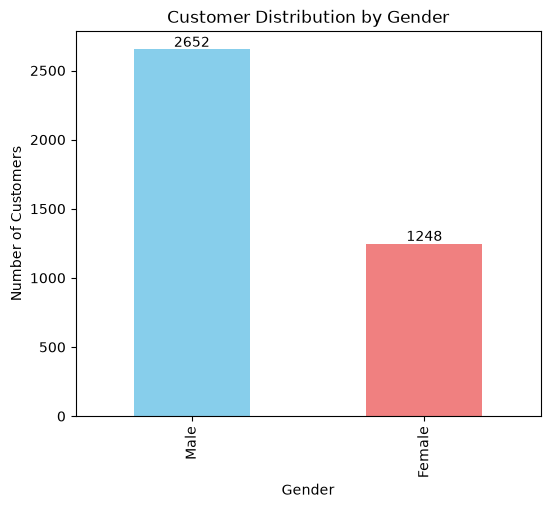

In [17]:
counts = df["gender"].value_counts()

ax = counts.plot(
    kind="bar",
    figsize=(6,5),
    color=["skyblue","lightcoral"]
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

for i, value in enumerate(counts):
    plt.text(i, value+20, str(value), ha="center")

plt.show()

Insight:

• Male customers are more than female customers.
• The dataset has a balanced representation of both genders.

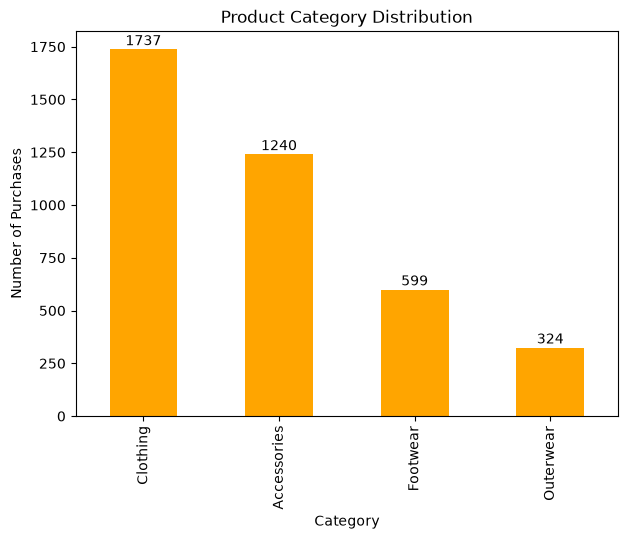

In [18]:
counts = df["category"].value_counts()

ax = counts.plot(
    kind="bar",
    figsize=(7,5),
    color="orange"
)

plt.title("Product Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Purchases")

for i, value in enumerate(counts):
    plt.text(i, value+20, str(value), ha="center")

plt.show()

Insight:

• Clothing has the highest number of purchases.
• Beauty and Footwear have comparatively fewer purchases.

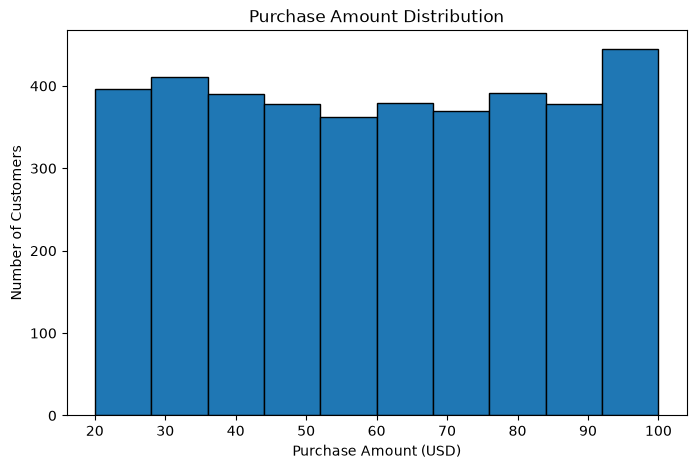

In [19]:
plt.figure(figsize=(8,5))

plt.hist(
    df["purchase_amount"],
    bins=10,
    edgecolor="black"
)

plt.title("Purchase Amount Distribution")
plt.xlabel("Purchase Amount (USD)")
plt.ylabel("Number of Customers")

plt.show()

### Insight

- Customer purchase amounts range from approximately 20 USD to 100 USD.
- Most purchase amounts are distributed across all price ranges.
- No extreme outliers are observed in the purchase amount distribution.

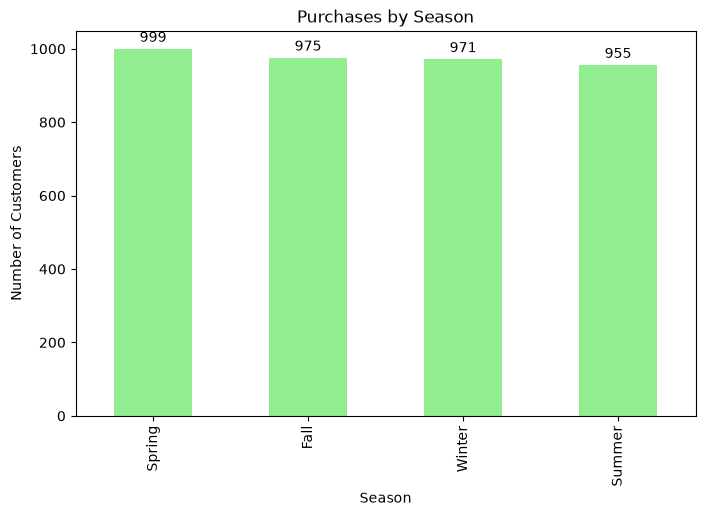

In [20]:
counts = df["season"].value_counts()

ax = counts.plot(
    kind="bar",
    figsize=(8,5),
    color="lightgreen"
)

plt.title("Purchases by Season")
plt.xlabel("Season")
plt.ylabel("Number of Customers")

for i, value in enumerate(counts):
    plt.text(i, value+20, str(value), ha="center")

plt.show()

### Insight

- Purchases are distributed across all seasons.
- Some seasons have slightly higher customer purchases than others.
- Seasonal trends can help businesses plan inventory and promotions.

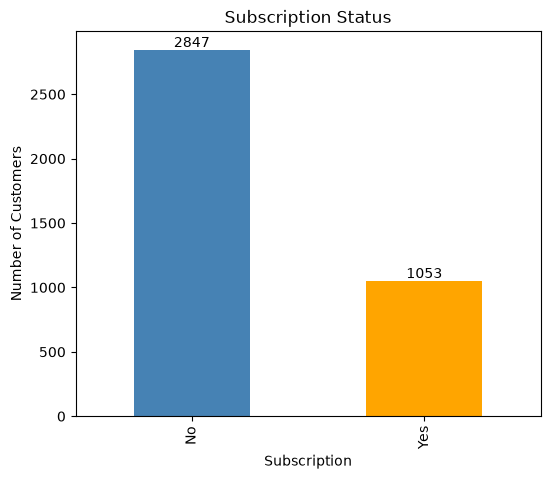

In [21]:
counts = df["subscription_status"].value_counts()

ax = counts.plot(
    kind="bar",
    figsize=(6,5),
    color=["steelblue", "orange"]
)

plt.title("Subscription Status")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")

for i, value in enumerate(counts):
    plt.text(i, value+20, str(value), ha="center")

plt.show()

### Insight

- The dataset contains both subscribed and non-subscribed customers.
- Subscription status can influence customer purchasing behavior.

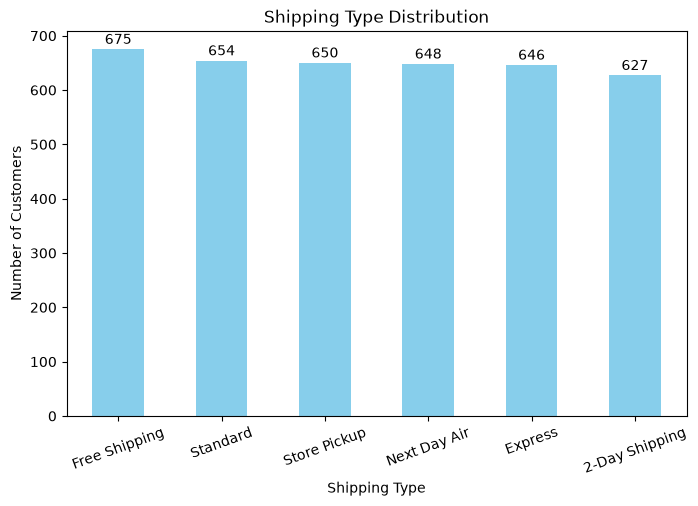

In [22]:
counts = df["shipping_type"].value_counts()

ax = counts.plot(
    kind="bar",
    figsize=(8,5),
    color="skyblue"
)

plt.title("Shipping Type Distribution")
plt.xlabel("Shipping Type")
plt.ylabel("Number of Customers")

for i, value in enumerate(counts):
    plt.text(i, value+10, str(value), ha="center")

plt.xticks(rotation=20)

plt.show()

### Insight

- Different shipping methods are used by customers.
- Some shipping methods are more popular than others.

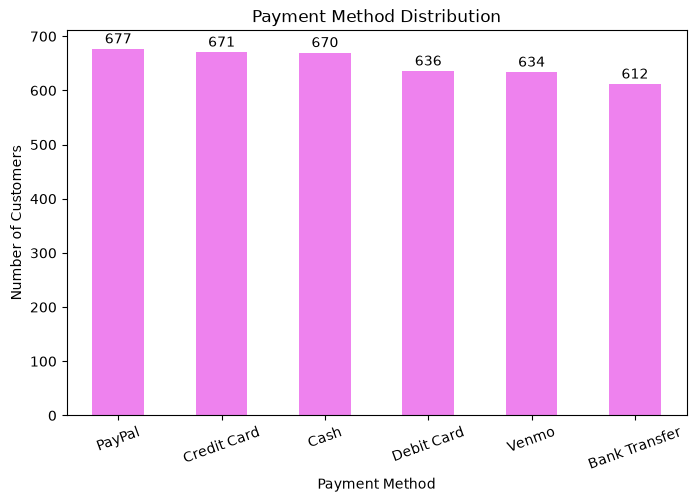

In [23]:
counts = df["payment_method"].value_counts()

ax = counts.plot(
    kind="bar",
    figsize=(8,5),
    color="violet"
)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

for i, value in enumerate(counts):
    plt.text(i, value+10, str(value), ha="center")

plt.xticks(rotation=20)

plt.show()

### Insight

- Customers use multiple payment methods.
- Payment preferences vary among customers.

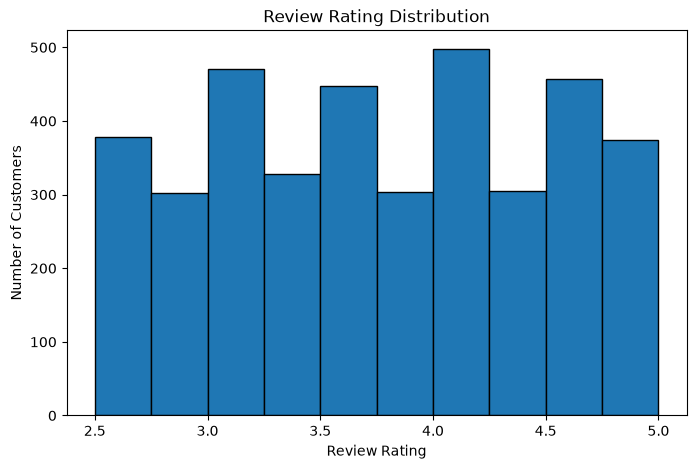

In [10]:

plt.figure(figsize=(8,5))

plt.hist(
    df['Review Rating'],
    bins=10,
    edgecolor='black'
)

plt.title("Review Rating Distribution")
plt.xlabel("Review Rating")
plt.ylabel("Number of Customers")

plt.show()

### Insight

- Most review ratings are between 2.5 and 4.5.
- Customer satisfaction appears to be moderate to high.

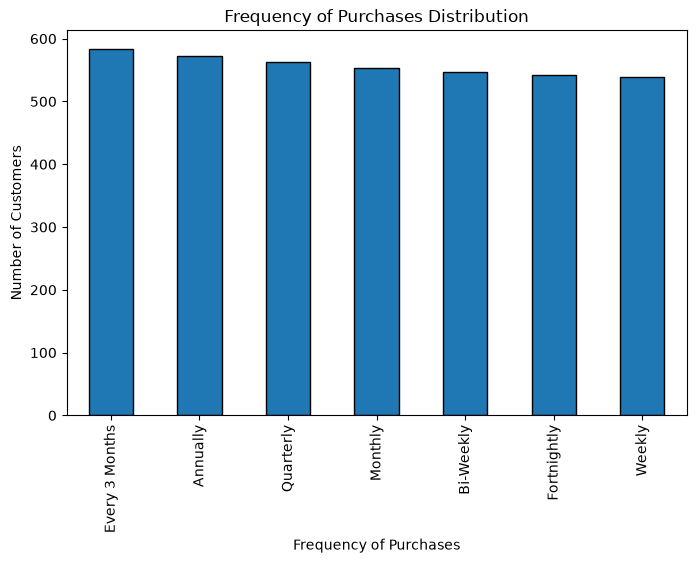

In [11]:
plt.figure(figsize=(8,5))

df['Frequency of Purchases'].value_counts().plot(
    kind='bar',
    edgecolor='black'
)

plt.title("Frequency of Purchases Distribution")
plt.xlabel("Frequency of Purchases")
plt.ylabel("Number of Customers")

plt.show()

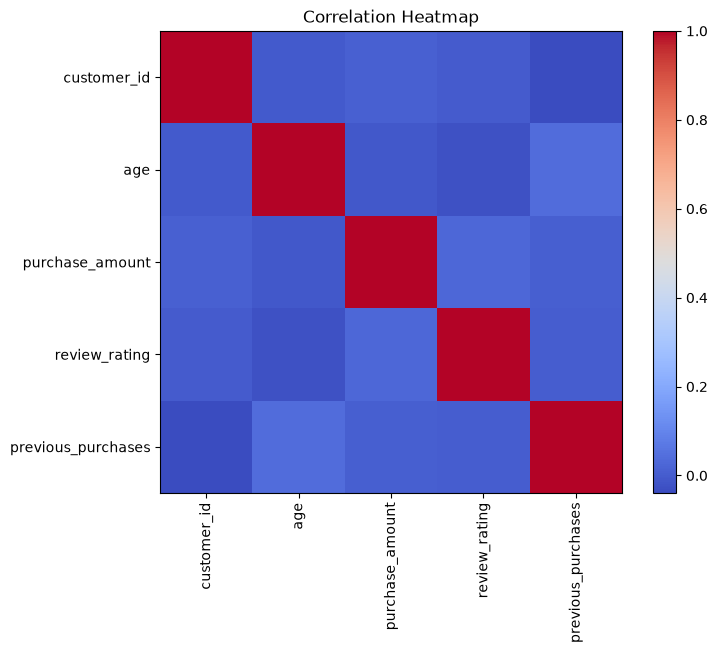

In [25]:
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(8,6))

plt.imshow(numeric_df.corr(), cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(numeric_df.columns)), numeric_df.columns, rotation=90)
plt.yticks(range(len(numeric_df.columns)), numeric_df.columns)

plt.title("Correlation Heatmap")

plt.show()

# Final Conclusion

- The dataset was cleaned and prepared successfully.
- Customer purchasing behavior was analyz--ed using different visualizations.
- Age group, gender, purchase amount, season, subscription status, shipping type, payment method, and review ratings were examined.
- The analysis provides useful insights that can help businesses understand customer preferences and improve decision-making.

### Insight

- The heatmap shows the relationship between numerical variables.
- Most variables have weak correlations with each other.

In [26]:
df.head(10)

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases,age_group
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,Senior
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,Young Adult
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,Middle Aged
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,Young Adult
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,Middle Aged
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Standard,Yes,Yes,14,Venmo,Weekly,Middle Aged
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Free Shipping,Yes,Yes,49,Cash,Quarterly,Senior
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Free Shipping,Yes,Yes,19,Credit Card,Weekly,Adult
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,2.6,Yes,Express,Yes,Yes,8,Venmo,Annually,Adult
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,4.8,Yes,2-Day Shipping,Yes,Yes,4,Cash,Quarterly,Senior


# Final Conclusion

This project analyzed customer shopping behavior using Python libraries such as Pandas and Matplotlib.

The dataset was cleaned, processed, and analyzed using different visualizations. Customer age groups, purchase amounts, product categories, seasonal purchases, payment methods, subscription status, shipping methods, and review ratings were studied.

The analysis provides meaningful insights into customer behavior and can help businesses make better marketing and sales decisions.

In [28]:
# Save cleaned dataset for SQL and Power BI

df.to_csv("customer_shopping_behavior_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   customer_id             3900 non-null   int64   
 1   age                     3900 non-null   int64   
 2   gender                  3900 non-null   str     
 3   item_purchased          3900 non-null   str     
 4   category                3900 non-null   str     
 5   purchase_amount         3900 non-null   int64   
 6   location                3900 non-null   str     
 7   size                    3900 non-null   str     
 8   color                   3900 non-null   str     
 9   season                  3900 non-null   str     
 10  review_rating           3900 non-null   float64 
 11  subscription_status     3900 non-null   str     
 12  shipping_type           3900 non-null   str     
 13  discount_applied        3900 non-null   str     
 14  promo_code_used         3900 non-nu

In [30]:
df.shape

(3900, 19)

In [31]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
item_purchased            0
category                  0
purchase_amount           0
location                  0
size                      0
color                     0
season                    0
review_rating             0
subscription_status       0
shipping_type             0
discount_applied          0
promo_code_used           0
previous_purchases        0
payment_method            0
frequency_of_purchases    0
age_group                 0
dtype: int64